## Time Analysis - City of Rome

## Objective

In order to have a deeper understanding of Rome's tourist numbers, we have gathered data from the official website of the Italian National Institute of Statistics - ISTAT. ISTAT Is the primary public research organization and main producer of official statistics in Italy.
This notebook aims to clean, analyze and visualize the data retrieved from this realiable source, to assist in the achievement of a better understandment and assesment of the tourism yearly behaviour.

In [270]:
#setup
from pathlib import Path
import pandas as pd
import numpy as np

# 1. Loading the dataset

In [271]:
Timeline = pd.read_csv("../data/Tourism_Rome.csv", skiprows=6, header=[0, 1])
Timeline = Timeline.iloc[1:].reset_index(drop=True)

# 2. Exploring the dataset

In [272]:
Timeline.shape

(24, 7)

In [273]:
Timeline.columns.tolist()

[('Indicatore  ', 'Tipologia di esercizio  '),
 ('Arrivi  ', 'Totale esercizi ricettivi  '),
 ('Arrivi  ', 'Esercizi alberghieri  '),
 ('Arrivi  ', 'Esercizi extra-alberghieri  '),
 ('Presenze  ', 'Totale esercizi ricettivi  '),
 ('Presenze  ', 'Esercizi alberghieri  '),
 ('Presenze  ', 'Esercizi extra-alberghieri  ')]

Since all the column names are in Italian, changing it to English assists in a easier identification.

In [274]:
Timeline.columns = [
    "Date",
    "Arrivals_Total",
    "Arrivals_Hotel",
    "Arrivals_NonHotel",
    "Overnights_Total",
    "Overnights_Hotel",
    "Overnights_NonHotel",
]

Timeline.columns.tolist()

['Date',
 'Arrivals_Total',
 'Arrivals_Hotel',
 'Arrivals_NonHotel',
 'Overnights_Total',
 'Overnights_Hotel',
 'Overnights_NonHotel']

Checking to see if there are any null rows.

In [302]:
Timeline.isna().sum()

Date                   0
Arrivals_Total         0
Arrivals_Hotel         0
Arrivals_NonHotel      0
Overnights_Total       0
Overnights_Hotel       0
Overnights_NonHotel    0
Month_num              0
dtype: int64

Understanding the type of data present in each column, and altering it to the most efficient format for each sort of data. Foreseen the necessity of a new column, which would correlate the dates with a month, this has been coded in this segment.

In [275]:
Timeline.info()

<class 'pandas.DataFrame'>
RangeIndex: 24 entries, 0 to 23
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   Date                 24 non-null     str  
 1   Arrivals_Total       24 non-null     str  
 2   Arrivals_Hotel       24 non-null     str  
 3   Arrivals_NonHotel    24 non-null     str  
 4   Overnights_Total     24 non-null     str  
 5   Overnights_Hotel     24 non-null     str  
 6   Overnights_NonHotel  24 non-null     str  
dtypes: str(7)
memory usage: 1.4 KB


In [276]:
for col in Timeline.columns:
    if col != "Date":
        Timeline[col] = pd.to_numeric(Timeline[col], errors="coerce")

Timeline["Date"] = Timeline["Date"].str.strip()
Timeline["Date_parsed"] = pd.to_datetime(Timeline["Date"], format="%Y-%m")
Timeline["Month_num"] = Timeline["Date_parsed"].dt.month

Timeline = Timeline.drop(columns=["Date_parsed"])

Timeline.dtypes

Date                     str
Arrivals_Total         int64
Arrivals_Hotel         int64
Arrivals_NonHotel      int64
Overnights_Total       int64
Overnights_Hotel       int64
Overnights_NonHotel    int64
Month_num              int32
dtype: object

In [277]:
Timeline.head()

,Date,Arrivals_Total,Arrivals_Hotel,Arrivals_NonHotel,Overnights_Total,Overnights_Hotel,Overnights_NonHotel,Month_num
0,2023-01,581156,463460,117696,2418079,1823784,594295,1
1,2023-02,596923,477391,119532,2487245,1902985,584260,2
2,2023-03,787147,626547,160600,3156680,2375254,781426,3
3,2023-04,899874,700136,199738,3682617,2684479,998138,4
4,2023-05,983629,764387,219242,3944900,2811086,1133814,5


# 3. Selection of Features
The selection of features was made foreseen the goal of the project: to predict the price of Airbnb in the city of Rome. Focusing on that, the two main features that are going to be used is (`Arrivals_Total`, `Overnights_Non_Hotel`,`Month_num`). Regarding the other features the reason why it was desconsidered is: 

#### (`Date`)
In order to optimize the desired information from this features, it was developed the (`Month_num`).
#### (`Arrivals_Hotel`, `Overnights_Hotel`)
Compreheending that our case is focus on Airbnb, our clientele is different. 
#### (`Arrivals_NonHotel`)
Interessant information, better approached by the (`Overnights_Non_Hotel`). Using both would be redundant,`Overnights_NonHotel` captures better the demand and also accounts for the duration of each stay.
#### (`Overnights_Total`)
Broad overview, could be misleading to the focus of our research.

In [278]:
Timeline_SF = Timeline[["Overnights_NonHotel", "Arrivals_Total","Month_num"]]

Timeline_SF.head()

,Overnights_NonHotel,Arrivals_Total,Month_num
0,594295,581156,1
1,584260,596923,2
2,781426,787147,3
3,998138,899874,4
4,1133814,983629,5


# 4. Grouping by Month

Once the data selection is arranged, it's important to group the date representing each month of the calendar. Therefore, we are able to achieve a mean of what each month would possibly look like.

In [279]:
MONTH_ORDER = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
               "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

monthly_avg_tourist_rome = (
    Timeline_SF.groupby("Month_num")
    .mean()
    .reindex(range(1, 13))
)
monthly_avg_tourist_rome.index = MONTH_ORDER
monthly_avg_tourist_rome

,Overnights_NonHotel,Arrivals_Total
Jan,655175.5,611077.0
Feb,729553.5,668552.5
Mar,922695.0,850380.0
Apr,1177876.0,952927.5
May,1339472.0,1058144.5
Jun,1328558.5,1063076.0
Jul,1428575.5,1078008.0
Aug,1146561.0,930673.0
Sep,1311166.0,1011597.0
Oct,1382126.5,1042932.0


# 5.Visualization 

Creating charts in order to visually asses the situation.

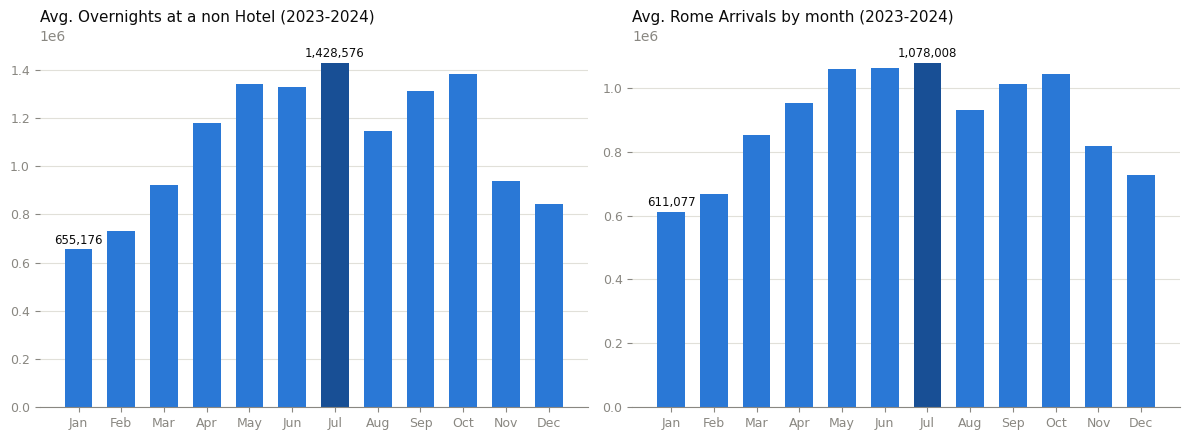

In [295]:
import matplotlib.pyplot as plt

colors = ["navy" if m == peak_month else "steelblue" for m in monthly_avg_tourist_rome.index]

metrics = [
    ("Overnights_NonHotel", "Avg. Overnights at a non Hotel (2023-2024)"),
    ("Arrivals_Total", "Avg. Rome Arrivals by month (2023-2024)"),
]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

for ax, (col, title) in zip(axes, metrics):
    values = monthly_avg_hotel[col]
    peak_month = values.idxmax()
    low_month = values.idxmin()
    colors = [BLUE_DARK if m == peak_month else BLUE for m in values.index]

    ax.bar(values.index, values.values, color=colors, width=0.65)

    ax.set_title(title, fontsize=11, color=INK, loc="left")
    ax.spines[["top", "right", "left"]].set_visible(False)
    ax.spines["bottom"].set_color(MUTED)
    ax.tick_params(axis="x", colors=MUTED, labelsize=9)
    ax.tick_params(axis="y", colors=MUTED, labelsize=9)
    ax.yaxis.grid(True, color=GRID, linewidth=0.8)
    ax.set_axisbelow(True)

    # direct labels only on the peak and the low month
    for month, val in values.items():
        if month in (peak_month, low_month):
            ax.annotate(
                f"{val:,.0f}",
                xy=(month, val),
                xytext=(0, 4),
                textcoords="offset points",
                ha="center",
                fontsize=8.5,
                color=INK,
            )

plt.tight_layout()
plt.show()

## 5.1 Heatmap: seasonality by month

Antoher view of the last seen chart. A heatmap version of the monthly averages above.

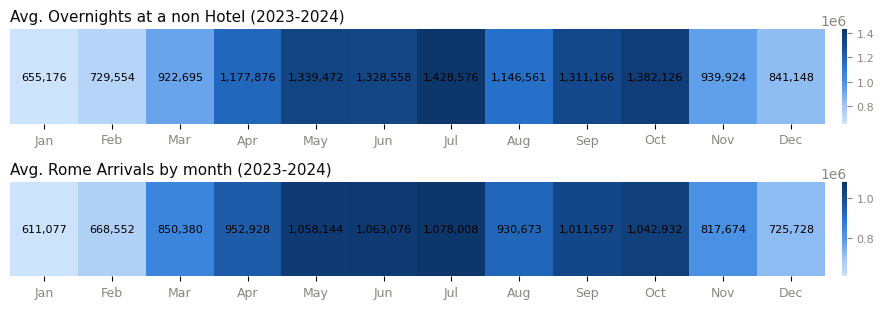

In [301]:
from matplotlib.colors import LinearSegmentedColormap

# Sequential ramp, same blue hue family as the bar chart above (light -> dark)
cmap = "Blues"

heat_metrics = [
    ("Overnights_NonHotel", "Avg. Overnights at a non Hotel (2023-2024)"),
    ("Arrivals_Total", "Avg. Rome Arrivals by month (2023-2024)")]


fig, axes = plt.subplots(2, 1, figsize=(9, 3.2))

for ax, (col, title) in zip(axes, heat_metrics):
    values = monthly_avg_tourist_rome[col].values.reshape(1, -1)

    im = ax.imshow(values, cmap=SEQ_BLUE, aspect="auto")

    ax.set_title(title, fontsize=11, color=INK, loc="left")
    ax.set_xticks(range(12))
    ax.set_xticklabels(MONTH_ORDER, fontsize=9, color=MUTED)
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)

    # direct value labels; flip to white ink on the darkest cells for contrast
    vmin, vmax = values.min(), values.max()
    for x, val in enumerate(values[0]):
        label_color = "black"
        ax.text(x, 0, f"{val:,.0f}", ha="center", va="center",
                fontsize=8, color=label_color)

    cbar = fig.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
    cbar.ax.tick_params(labelsize=8, colors=MUTED)
    cbar.outline.set_visible(False)

plt.tight_layout()
plt.show()

# 6.Seasonality index:

`Arrivals_Total` and `Overnights_Non_Hotel` have different scales, therefore normalizing both values, assures us to capture the canging points. We min-max normalize each metric across the 12 months, then combine them into one weighted composite:

`Seasonality_Index = 0.3 * norm(Arrivals_Total) + 0.7 * norm(Overnights_Non_Hotel)`

Overnight non Hotel stays get more weight (0.7) because they better reflect how long
tourists actually stay in Rome and the actual business we are trying to understand - people who are staying in the city but not in Hotels. While arrivals (0.3) only count how many visited rome, still interesting because reflect a broader demand, without distinguish of who is actually is staying in the city and who is not - this being the reason why is accounted less.

In [288]:
WEIGHTS = {"Overnights_NonHotel": 0.7, "Arrivals_Total": 0.3}

normalized_tourists_rome = (monthly_avg_tourist_rome - monthly_avg_tourist_rome.min()) / (
    monthly_avg_tourist_rome.max() - monthly_avg_tourist_rome.min()
)

seasonality_index = (
    normalized_tourists_rome["Overnights_NonHotel"] * WEIGHTS["Overnights_NonHotel"]
    + normalized_tourists_rome["Arrivals_Total"] * WEIGHTS["Arrivals_Total"]
)
seasonality_index.name = "Seasonality_Index"
seasonality_index.round(3)

Jan    0.000
Feb    0.104
Mar    0.396
Apr    0.693
May    0.907
Jun    0.900
Jul    1.000
Aug    0.650
Sep    0.851
Oct    0.935
Nov    0.390
Dec    0.242
Name: Seasonality_Index, dtype: float64

## 6.1 Index Charts

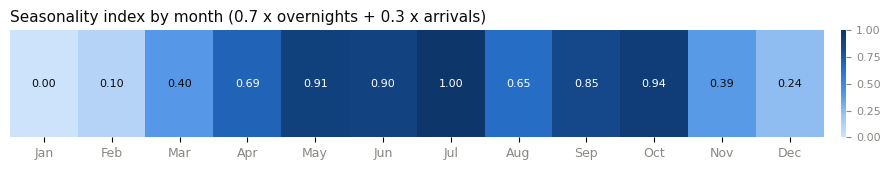

In [289]:
fig, ax = plt.subplots(figsize=(9, 1.8))

values = seasonality_index.values.reshape(1, -1)
im = ax.imshow(values, cmap=SEQ_BLUE, aspect="auto", vmin=0, vmax=1)

ax.set_title("Seasonality index by month (0.7 x overnights + 0.3 x arrivals)",
             fontsize=11, color=INK, loc="left")
ax.set_xticks(range(12))
ax.set_xticklabels(MONTH_ORDER, fontsize=9, color=MUTED)
ax.set_yticks([])
for spine in ax.spines.values():
    spine.set_visible(False)

for x, val in enumerate(values[0]):
    label_color = "#ffffff" if val > 0.6 else INK
    ax.text(x, 0, f"{val:.2f}", ha="center", va="center",
            fontsize=8, color=label_color)

cbar = fig.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
cbar.ax.tick_params(labelsize=8, colors=MUTED)
cbar.outline.set_visible(False)

plt.tight_layout()
plt.show()

# 7. Adding features 

Feaures such as (`season`),(`month_sin`),(`month_cos`) were added. The (`season`) could be a important feature since, as foreseen, seasons have a correlation with the amount of tourist in ROME, months such as winter tend to have a low amount of visitors, January. The (`month_sin`),(`month_cos`) were used in order to help the informatic approach of the yearly understanding.

In [291]:
SEASON_MAP = {
    1: "Winter", 2: "Winter",
    3: "Spring", 4: "Spring",  5: "Spring",
    6: "Summer", 7: "Summer",  8: "Summer",
    9: "Fall",  10: "Fall",   11: "Fall",
    12: "Winter",
}

peak_month_num = MONTH_ORDER.index(seasonality_index.idxmax()) + 1
low_month_num  = MONTH_ORDER.index(seasonality_index.idxmin()) + 1

month_features = pd.DataFrame({
    "Month_num":         range(1, 13),
    "Seasonality_Index": seasonality_index.values,
})
month_features["season"]        = month_features["Month_num"].map(SEASON_MAP)
month_features["month_sin"]     = np.sin(2 * np.pi * month_features["Month_num"] / 12)
month_features["month_cos"]     = np.cos(2 * np.pi * month_features["Month_num"] / 12)

month_features

,Month_num,Seasonality_Index,season,month_sin,month_cos
0,1,0.000000,Winter,5.000000e-01,8.660254e-01
1,2,0.104247,Winter,8.660254e-01,5.000000e-01
2,3,0.395881,Spring,1.000000e+00,6.123234e-17
3,4,0.692730,Spring,8.660254e-01,-5.000000e-01
4,5,0.906591,Spring,5.000000e-01,-8.660254e-01
5,6,0.899881,Summer,1.224647e-16,-1.000000e+00
6,7,1.000000,Summer,-5.000000e-01,-8.660254e-01
7,8,0.650089,Summer,-8.660254e-01,-5.000000e-01
8,9,0.851065,Fall,-1.000000e+00,-1.836970e-16
9,10,0.935423,Fall,-8.660254e-01,5.000000e-01


# 8. Export to CSV


In [ ]:
month_features.to_csv("../data/seasonality_features.csv", index=False)
print("seasonality_features.csv saved")
month_features